# Daily Quant Swing Screener

**Open this every day, run all cells (top to bottom), read the BUY NOW / CLOSE TO BUY tables.**

Scans the top most-mentioned r/wallstreetbets tickers on **daily candles** and sorts every
name into an actionable bucket. Tuned for a swing hold of **>= 10 trading days**, and built to
fire *before* the big move.

### The 0-100 score blends (all in `wsb_screener/quant_core.py`)
- **Golden cross regime** (50/200 SMA) + price above the 200-SMA  — trade with the long trend
- **Bull Market Support Band** (20 SMA / 21 EMA)  — short-term support / reclaim
- **12-1 time-series momentum**  — trend persistence over the past year
- **Volatility squeeze** (Bollinger inside Keltner)  — coiled energy that precedes a big move
- **20-day breakout + volume**  — trend ignition
- **RSI(14) & MACD(12,26,9)**  — momentum confirmation / overbought guard

### Buckets
- **BUY NOW** — regime bullish, score high, *and* a fresh trigger fired today. Act at next open.
- **CLOSE TO BUY** — strong + coiling, no trigger yet. Watch these.
- **HOLD (UPTREND)** — already trending above the band; hold if long, a new buy is chasing.
- **SELL / EXIT** — just lost the band or death-crossed. If you hold it, get out.
- **WATCH** — regime/score too weak. Nothing to do.

Each row also carries a **>= 10-day-hold swing backtest** (win rate, expectancy per $1,000).

> **Research only, not financial advice.**

```bash
pip install -r requirements.txt
```

## 1. Config — edit me

In [1]:
TOP_N    = 200     # how many WSB tickers to scan
PERIOD   = "3y"    # daily history length (>= ~1.5y so the 200-SMA + 12m momentum warm up)
INTERVAL = "1d"    # daily = refresh every day
OUTDIR   = "results"

from wsb_screener import quant_screener as qscr
from wsb_screener.quant_report import build_markdown
from wsb_screener.data import get_wsb_tickers, download_history
import pandas as pd
pd.set_option("display.max_rows", 250, "display.width", 260, "display.max_columns", 60)

## 2. Fetch the WSB universe + daily price history

In [2]:
tickers = get_wsb_tickers(TOP_N)
metas   = {t["ticker"]: t for t in tickers}
print(f"Top {len(metas)} r/wallstreetbets tickers by mention count")
print(", ".join(list(metas)[:25]), "...")

hist = download_history(list(metas), period=PERIOD, interval=INTERVAL)
print(f"\nDownloaded daily price data for {len(hist)}/{len(metas)} tickers")

Top 200 r/wallstreetbets tickers by mention count
MU, SPY, NVDA, SNDK, QQQ, MSFT, SPCX, DTE, NBIS, WEN, TSLA, USO, PENG, AVGO, SOXL, META, RKLB, AMD, ORCL, AM, GOOG, IT, BABA, MRVL, DELL ...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DAY"}}}


$RE: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")


$DAY: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")



2 Failed downloads:


['RE', 'DAY']: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")


$GPS: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")



1 Failed download:


['GPS']: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")



Downloaded daily price data for 197/200 tickers


## 3. Run the model (score → trigger → bucket)

In [3]:
df = qscr.run_screener(hist, metas)
signal_date = df["signal_date"].dropna().mode().iloc[0]
print("Latest daily bar:", signal_date)
df["group"].value_counts()

  ...screened 25/200


  ...screened 50/200


  ...screened 75/200


  ...screened 100/200


  ...screened 125/200


  ...screened 150/200


  ...screened 175/200


  ...screened 200/200
Latest daily bar: 2026-07-08


group
WATCH             65
SELL / EXIT       54
CLOSE TO BUY      50
HOLD (UPTREND)    14
BUY NOW           12
SKIPPED            5
Name: count, dtype: int64

## 4. BUY NOW — fresh, high-score entries on the latest bar
Regime bullish + score clears the buy threshold + a trigger fired today. Act at next open.

In [4]:
buy_cols = ["group_rank","ticker","name","close","score","golden","rsi","mom_12_1_%",
            "squeeze_on","vol_ratio","band_bot","band_top","need_move_%",
            "bt_trades","bt_winrate_%","bt_expectancy_$","note"]
df[df.group=="BUY NOW"][buy_cols]

,group_rank,ticker,name,close,score,golden,rsi,mom_12_1_%,squeeze_on,vol_ratio,band_bot,band_top,need_move_%,bt_trades,bt_winrate_%,bt_expectancy_$,note
0,1,ANET,Arista Networks,178.32,93.1,True,55.6,52.0,True,0.91,164.77,165.29,-2.11,28.0,50.0,17.83,"entry trigger: 20-day breakout, squeeze fired ..."
1,2,PENG,Penguin Solutions,77.78,91.8,True,61.9,185.9,True,2.86,65.10,65.54,-2.28,15.0,46.7,135.25,"entry trigger: 20-day breakout, reclaimed the ..."
2,3,DELL,Dell,428.86,87.7,True,56.6,220.9,True,0.95,402.27,409.68,1.21,19.0,57.9,96.13,entry trigger: squeeze fired up (act at next o...
3,4,AAPL,Apple,314.24,84.3,True,60.0,47.0,False,0.37,295.68,298.96,-0.50,19.0,57.9,19.91,entry trigger: 20-day breakout (act at next open)
4,5,AVGO,Broadcom,389.65,79.8,True,54.5,41.5,True,0.67,380.72,384.91,5.40,27.0,48.1,45.87,entry trigger: reclaimed the band (act at next...
5,6,WTI,W&T Offshore,3.65,76.7,True,65.3,118.7,False,1.38,3.41,3.42,17.26,15.0,33.3,6.97,entry trigger: reclaimed the band (act at next...
6,7,XLE,SSgA Active Trust - SSgA Energy Select Sector ...,55.38,75.9,True,52.6,37.0,False,0.85,54.62,54.72,4.57,23.0,21.7,5.52,entry trigger: reclaimed the band (act at next...
7,8,TXN,Texas Instruments,305.58,72.7,True,50.0,37.3,False,0.38,300.02,301.35,8.74,21.0,52.4,29.32,entry trigger: reclaimed the band (act at next...
8,9,ET,Energy Transfer Partners,19.90,72.1,True,70.5,17.7,False,0.79,19.11,19.28,-0.43,26.0,50.0,10.81,entry trigger: 20-day breakout (act at next open)
9,10,NVDA,NVIDIA,202.66,71.7,True,45.0,29.6,False,0.62,201.62,201.92,4.83,27.0,40.7,27.70,entry trigger: reclaimed the band (act at next...


## 5. CLOSE TO BUY — strong and coiling, waiting on the trigger
A squeeze is coiled, price is a few % under the 20-day high, or it's hugging the band.

In [5]:
near_cols = ["group_rank","ticker","name","close","score","pos_vs_band","prox_high_%",
             "squeeze_on","rsi","mom_12_1_%","band_bot","band_top","note"]
df[df.group=="CLOSE TO BUY"][near_cols]

,group_rank,ticker,name,close,score,pos_vs_band,prox_high_%,squeeze_on,rsi,mom_12_1_%,band_bot,band_top,note
12,1,ADM,Archer Daniels Midland,80.39,89.7,above,1.11,False,60.2,53.1,77.66,77.84,1.1% under the 20-day high -- watch for the tr...
13,2,ZETA,Zeta Global,21.47,89.7,above,1.86,False,59.2,48.1,19.90,20.27,1.9% under the 20-day high -- watch for the tr...
14,3,YOU,CLEAR Secure,55.44,86.2,above,2.35,False,59.7,92.8,53.41,54.61,2.4% under the 20-day high -- watch for the tr...
15,4,OUT,Outfront Media,33.08,82.3,above,0.48,False,68.5,93.7,31.93,32.27,0.5% under the 20-day high -- watch for the tr...
16,5,CVS,CVS Health,104.54,81.2,above,0.26,False,61.6,49.1,101.19,101.88,0.3% under the 20-day high -- watch for the tr...
17,6,MO,Altria Group,73.10,80.1,above,1.30,False,62.1,26.1,71.50,71.69,1.3% under the 20-day high -- watch for the tr...
18,7,HUM,Humana,397.00,79.0,above,3.13,False,67.2,49.4,373.07,377.78,3.1% under the 20-day high -- watch for the tr...
19,8,MS,Morgan Stanley,218.54,78.8,above,3.91,False,47.6,51.0,215.43,217.29,3.9% under the 20-day high -- watch for the tr...
20,9,LLY,Eli Lilly,1226.50,78.3,above,0.74,False,69.0,47.4,1159.84,1161.65,0.7% under the 20-day high -- watch for the tr...
21,10,RY,Royal Bank Of Canada,206.35,78.2,above,1.32,False,61.9,49.5,202.17,202.98,1.3% under the 20-day high -- watch for the tr...


## 6. HOLD (uptrend) / SELL (exit) / WATCH

In [6]:
hold_cols = ["group_rank","ticker","name","close","score","rsi","mom_12_1_%",
             "band_bot","band_top","bt_winrate_%","bt_expectancy_$"]
sell_cols = ["group_rank","ticker","name","close","score","pos_vs_band","band_bot","band_top","rsi","note"]
watch_cols= ["group_rank","ticker","name","close","score","regime_ok","pos_vs_band","rsi","mom_12_1_%"]
from IPython.display import display
print("HOLD (UPTREND)"); display(df[df.group=="HOLD (UPTREND)"][hold_cols].head(25))
print("SELL / EXIT");    display(df[df.group=="SELL / EXIT"][sell_cols])
print("WATCH");          display(df[df.group=="WATCH"][watch_cols].head(25))

HOLD (UPTREND)


,group_rank,ticker,name,close,score,rsi,mom_12_1_%,band_bot,band_top,bt_winrate_%,bt_expectancy_$
62,1,GEV,GE Vernova,1090.15,70.4,58.3,76.4,1047.36,1067.28,47.6,82.09
63,2,SLS,Sellas Life Sciences,12.47,69.2,67.2,279.3,10.48,11.19,31.2,34.59
64,3,FOR,Forestar Group,30.09,67.1,58.1,35.0,29.90,29.97,33.3,-4.38
65,4,BB,BlackBerry,10.95,67.0,61.9,118.3,10.13,10.33,50.0,109.76
66,5,RIVN,Rivian,16.58,62.7,52.7,28.2,16.32,16.58,33.3,-39.07
67,6,RDDT,Reddit,192.77,60.7,59.2,13.1,176.95,179.13,50.0,152.79
68,7,BY,Byline Bancorp,36.78,59.5,65.7,22.0,36.19,36.23,52.4,17.92
69,8,LOVE,LoveSac,16.56,57.6,64.1,-15.3,16.12,16.40,25.0,-8.48
70,9,BA,Boeing,224.21,57.3,46.7,-1.5,221.44,222.61,56.2,7.78
71,10,SGOV,iShares Trust - iShares 0-3 Month Treasury Bon...,100.47,53.6,NaN,3.3,100.32,100.34,100.0,2.45


SELL / EXIT


,group_rank,ticker,name,close,score,pos_vs_band,band_bot,band_top,rsi,note
76,1,CAVA,CAVA Group,67.82,17.4,below,78.40,81.25,24.0,exit signal: lost the support band
77,2,AGI,Alamos Gold,29.06,19.2,below,32.84,32.93,17.4,exit signal: lost the support band
78,3,LINK,Interlink Electronics,4.05,24.7,below,4.29,4.31,46.1,exit signal: lost the support band
79,4,EL,Estee Lauder,81.46,25.2,below,83.30,84.17,36.5,exit signal: lost the support band
80,5,SAP,SAP,157.91,25.3,below,159.57,161.53,42.6,exit signal: lost the support band
81,6,AVAV,AeroVironment,159.29,26.9,below,163.12,166.10,47.0,exit signal: lost the support band
82,7,CME,CME Group,245.07,27.3,above,243.50,243.54,38.7,exit signal: death cross / below 200-SMA
83,8,AVY,Avery Dennison,157.11,27.4,below,161.28,161.58,42.1,exit signal: lost the support band
84,9,DIS,Walt Disney,97.43,27.6,below,98.93,99.08,42.5,exit signal: lost the support band
85,10,AEM,Agnico Eagle Mines,144.54,27.7,below,159.07,159.60,14.5,exit signal: lost the support band


WATCH


,group_rank,ticker,name,close,score,regime_ok,pos_vs_band,rsi,mom_12_1_%
130,1,GOAT,VanEck Vectors ETF Trust - VanEck Vectors Morn...,38.58,57.1,False,above,52.7,8.0
131,2,KORU,Direxion Shares ETF Trust - Direxion Daily Sou...,535.80,56.6,True,below,34.6,721.9
132,3,NOK,Nokia,11.81,56.6,True,below,32.0,183.4
133,4,OPEN,Opendoor,4.74,56.4,False,above,49.7,606.1
134,5,AAOI,Applied Optoelectronics,114.86,55.1,True,below,24.4,569.4
135,6,IQ,iQIYI,1.07,54.9,False,above,53.1,-40.7
136,7,ON,ON Semiconductor,93.09,53.3,True,below,36.2,114.7
137,8,ARM,Arm Holdings,295.49,52.9,True,below,29.1,133.5
138,9,RKLB,Rocket Lab USA,82.53,52.9,True,below,34.5,183.1
139,10,CBOE,Cboe,267.95,52.6,False,above,51.4,20.4


## 7. Save the scan (CSV + Markdown report)

In [7]:
import os
os.makedirs(OUTDIR, exist_ok=True)
df.to_csv(f"{OUTDIR}/wsb_quant_screen.csv", index=False)
with open(f"{OUTDIR}/wsb_quant_report.md", "w") as f:
    f.write(build_markdown(df, len(metas), signal_date))
print("wrote", f"{OUTDIR}/wsb_quant_screen.csv", "and", f"{OUTDIR}/wsb_quant_report.md")

wrote results/wsb_quant_screen.csv and results/wsb_quant_report.md


## 8. (Optional) Drill into one ticker
Price + 20/21 support band + 50/200 SMAs (golden cross) + the >=10-day-hold backtest trades,
then the component score breakdown.

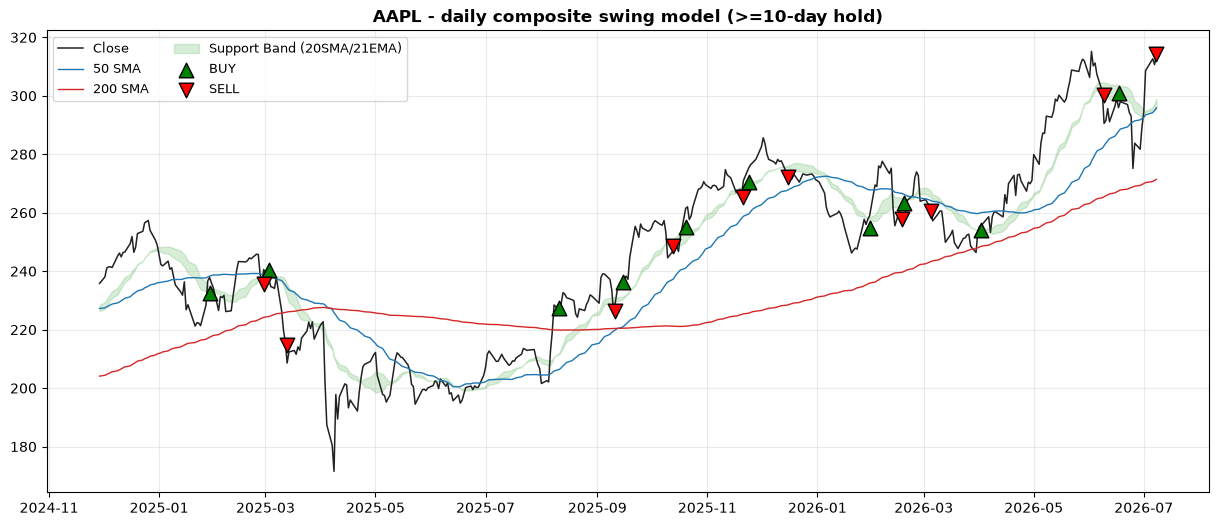

AAPL  score=84.3  ->  BUY NOW
component scores (0-100): {'regime': 100.0, 'band': 100.0, 'mom': 94.0, 'macd': 100.0, 'rsi': 100.0, 'squeeze': 35.0, 'breakout': 60.0}
backtest (>=10-day hold): {'Total Trades': 19, 'Win Rate %': 57.9, 'Total P&L $': np.float64(378.34), 'Avg Win $': np.float64(64.03), 'Avg Loss $': np.float64(-40.75), 'Profit Factor': np.float64(2.16), 'Expectancy $': np.float64(19.91), 'Avg Bars Held': np.float64(20.9), 'Max Drawdown $': np.float64(-111.43), 'Return/Trade %': np.float64(1.99)}


In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
from wsb_screener.quant_core import swing_backtest, compute_stats, live_signal

SYMBOL = "AAPL"   # <- pick any ticker from the tables above (the WSB universe changes daily)

# fall back to a valid, screened ticker if SYMBOL isn't in today's universe
if SYMBOL not in set(df.ticker) or SYMBOL not in hist:
    pref = [x for x in df[df.group.isin(["BUY NOW", "CLOSE TO BUY"])].ticker if x in hist]
    pref = pref or [x for x in df.ticker if x in hist]
    SYMBOL = pref[0]
    print(f"(SYMBOL not in today's table -> showing {SYMBOL}; edit SYMBOL to any ticker above)")

d, t = swing_backtest(hist[SYMBOL])
view = d.tail(400)   # last ~1.5y for readability

fig, ax = plt.subplots(figsize=(15,6))
ax.plot(view.Date, view.Close, color="#222", lw=1.1, label="Close")
ax.plot(view.Date, view.SMA50,  color="#1f77b4", lw=1.0, label="50 SMA")
ax.plot(view.Date, view.SMA200, color="#d62728", lw=1.0, label="200 SMA")
ax.fill_between(view.Date, view.band_bot, view.band_top, color="#2ca02c", alpha=0.18,
                label="Support Band (20SMA/21EMA)")
tv = t[t.entry_date >= view.Date.iloc[0]] if not t.empty else t
if not tv.empty:
    ax.scatter(tv.entry_date, tv.entry_price, marker="^", s=110, color="green", edgecolor="k", zorder=5, label="BUY")
    ax.scatter(tv.exit_date,  tv.exit_price,  marker="v", s=110, color="red",   edgecolor="k", zorder=5, label="SELL")
ax.set_title(f"{SYMBOL} - daily composite swing model (>=10-day hold)", weight="bold")
ax.legend(loc="upper left", ncol=2, fontsize=9); ax.grid(alpha=0.25)
plt.show()

sig = live_signal(hist[SYMBOL])
print(f"{SYMBOL}  score={sig['score']}  ->  {df[df.ticker==SYMBOL].group.iloc[0]}")
print("component scores (0-100):",
      {k[2:]: sig[k] for k in ("s_regime","s_band","s_mom","s_macd","s_rsi","s_squeeze","s_breakout")})
print("backtest (>=10-day hold):", compute_stats(t))